# Week 06 Lab Work

**Dataset:** Adult / Census Income (UCI Machine Learning Repository)

1. Load the data.
2. Normalize the data (min-max, z-score, decimal scaling).
3. Smooth and discretize the data (equal-width, equal-frequency, clustering, bin means).
4. Reduce the dimensions (attribute creation, attribute subset selection, PCA).
5. Reduce the number of rows (sampling, histogram, regression).


In [1]:
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, KBinsDiscretizer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

cols = ["age", "workclass", "fnlwgt", "education", "education-num",
        "marital-status", "occupation", "relationship", "race", "sex",
        "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]


def get_file(data_filename):
    for base in [".", ".."]:
        if not os.path.isdir(base):
            continue
        for root, dirs, files in os.walk(base):
            if data_filename in files:
                return os.path.join(root, data_filename)

    print(f"'{data_filename}' not found in the workspace. Downloading it dynamically...")
    url = f"https://archive.ics.uci.edu/ml/machine-learning-databases/adult/{data_filename}"
    urllib.request.urlretrieve(url, data_filename)
    return data_filename


# 1. Load the data
path = get_file("adult.data")
print(f"Loading data from: {path}")
df = pd.read_csv(path, header=None, names=cols, skipinitialspace=True, na_values="?")
df = df.dropna().reset_index(drop=True)
print("Shape:", df.shape)
df.head()

Loading data from: ../Task_No_3 (week 4)/adult dataset/adult.data
Shape: (30162, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. Normalization

In [2]:
# Min-max normalization
df["age_minmax"] = MinMaxScaler().fit_transform(df[["age"]])

# Z-score normalization
df["hours_zscore"] = StandardScaler().fit_transform(df[["hours-per-week"]])

# Decimal scaling
digits = len(str(int(df["fnlwgt"].abs().max())))
df["fnlwgt_decimal"] = df["fnlwgt"] / 10 ** digits

print(df[["age", "age_minmax", "hours-per-week", "hours_zscore",
          "fnlwgt", "fnlwgt_decimal"]].head())

   age  age_minmax  hours-per-week  hours_zscore  fnlwgt  fnlwgt_decimal
0   39    0.301370              40     -0.077734   77516        0.007752
1   50    0.452055              13     -2.331531   83311        0.008331
2   38    0.287671              40     -0.077734  215646        0.021565
3   53    0.493151              40     -0.077734  234721        0.023472
4   28    0.150685              40     -0.077734  338409        0.033841


## 3. Smoothing and discretization

In [3]:
# Equal-width binning
df["age_equal_width"] = pd.cut(df["age"], bins=3, labels=["Young", "Middle", "Senior"])

# Equal-frequency (equi-depth) binning
df["age_equal_freq"] = pd.qcut(df["age"], q=3, labels=["Low", "Medium", "High"])

# Discretization by clustering
df["age_kmeans"] = KBinsDiscretizer(n_bins=3, encode="ordinal",
                                    strategy="kmeans").fit_transform(df[["age"]])

# Smoothing by bin means
df["age_smoothed"] = df.groupby("age_equal_freq", observed=False)["age"].transform("mean")

print(df[["age", "age_equal_width", "age_equal_freq", "age_kmeans", "age_smoothed"]].head(10))

   age age_equal_width age_equal_freq  age_kmeans  age_smoothed
0   39           Young         Medium         1.0     37.829292
1   50          Middle           High         1.0     54.213764
2   38           Young         Medium         1.0     37.829292
3   53          Middle           High         2.0     54.213764
4   28           Young            Low         0.0     24.774694
5   37           Young         Medium         1.0     37.829292
6   49          Middle           High         1.0     54.213764
7   52          Middle           High         2.0     54.213764
8   31           Young            Low         0.0     24.774694
9   42          Middle         Medium         1.0     37.829292


## 4. Dimensionality reduction

In [4]:
y = (df["income"] == ">50K").astype(int)
X = df[["age", "fnlwgt", "education-num", "capital-gain",
        "capital-loss", "hours-per-week"]].copy()

# Attribute creation
X["net-capital"] = X["capital-gain"] - X["capital-loss"]
X["gain-per-hour"] = X["capital-gain"] / X["hours-per-week"]

# Attribute subset selection
selector = SelectKBest(score_func=f_classif, k=4).fit(X, y)
selected = X.columns[selector.get_support()]
print("Top 4 features:", list(selected))

# Principal component analysis
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance of 2 components:", pca.explained_variance_ratio_)
print("Shape before PCA:", X.shape, "-> after PCA:", X_pca.shape)

Top 4 features: ['age', 'education-num', 'capital-gain', 'hours-per-week']
Explained variance of 2 components: [0.35643538 0.15656724]
Shape before PCA: (30162, 8) -> after PCA: (30162, 2)


## 5. Numerosity reduction

In [5]:
# Simple random sampling without replacement
srswor = df.sample(frac=0.2, replace=False, random_state=42)

# Simple random sampling with replacement
srswr = df.sample(frac=0.2, replace=True, random_state=42)

# Stratified sampling
stratified, _ = train_test_split(df, train_size=0.2, stratify=df["income"], random_state=42)

print("Sample sizes -> SRSWOR:", len(srswor), "SRSWR:", len(srswr),
      "Stratified:", len(stratified))
print("\nOriginal income share:\n", df["income"].value_counts(normalize=True))
print("\nStratified income share:\n", stratified["income"].value_counts(normalize=True))

Sample sizes -> SRSWOR: 6032 SRSWR: 6032 Stratified: 6032

Original income share:
 income
<=50K    0.751078
>50K     0.248922
Name: proportion, dtype: float64

Stratified income share:
 income
<=50K    0.750995
>50K     0.249005
Name: proportion, dtype: float64


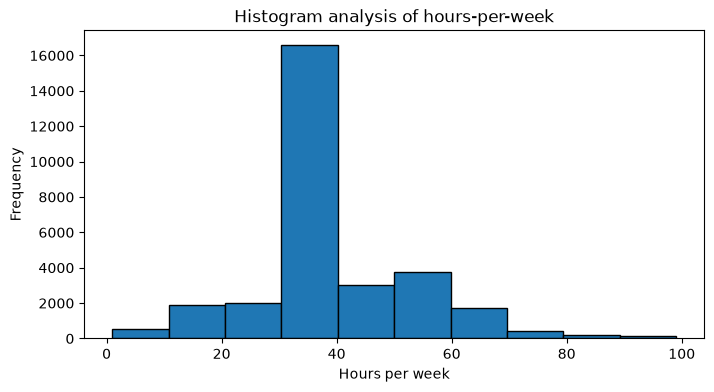

Coefficients: [ 39.21081907 327.69181935  34.71882277]
Intercept: -5152.929167625417
R-squared: 0.024127785531229073


In [6]:
# Histogram analysis
plt.figure(figsize=(8, 4))
plt.hist(df["hours-per-week"], bins=10, edgecolor="black")
plt.title("Histogram analysis of hours-per-week")
plt.xlabel("Hours per week")
plt.ylabel("Frequency")
plt.show()

# Parametric reduction by regression
X_reg = df[["age", "education-num", "hours-per-week"]]
y_reg = df["capital-gain"]

model = LinearRegression().fit(X_reg, y_reg)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("R-squared:", model.score(X_reg, y_reg))